In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
np.random.seed(42)
n = 200

study_hours = np.random.uniform(1, 10, n)
sleep_hours = np.random.uniform(4, 10, n)
attendance = np.random.uniform(50, 100, n)
prev_score = np.random.uniform(40, 100, n)

exam_score = (3.5 * study_hours + 2.0 * sleep_hours + 0.3 * attendance + 0.4 * prev_score + np.random.normal(0, 3, n)).clip(0, 100).round(2)

data = pd.DataFrame({
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'attendance': attendance,
    'prev_score': prev_score,
    'exam_score': exam_score
})

print(data.head())
print("\nDataset shape:", data.shape)

   study_hours  sleep_hours  attendance  prev_score  exam_score
0     4.370861     7.852190   55.156193   50.136104       65.23
1     9.556429     4.504840   95.127645   56.715420       95.10
2     7.587945     4.969772   75.262619   50.620629       84.97
3     6.387926     9.391325   91.322873   45.322152       90.70
4     2.404168     7.638574   66.002480   47.238152       67.17

Dataset shape: (200, 5)


Basic Statistics:
       study_hours  sleep_hours  attendance  prev_score  exam_score
count   200.000000   200.000000  200.000000  200.000000  200.000000
mean      5.356056     7.026251   76.033639   68.726269   82.574150
std       2.654023     1.758007   15.365440   16.730075   12.003692
min       1.049699     4.030370   50.541883   41.086611   50.390000
25%       3.057242     5.568775   62.776016   54.158396   74.210000
50%       5.450376     7.249839   76.269974   68.027679   84.785000
75%       7.811737     8.453196   90.555744   83.464378   91.997500
max       9.881982     9.943031   99.985884   99.397614  100.000000


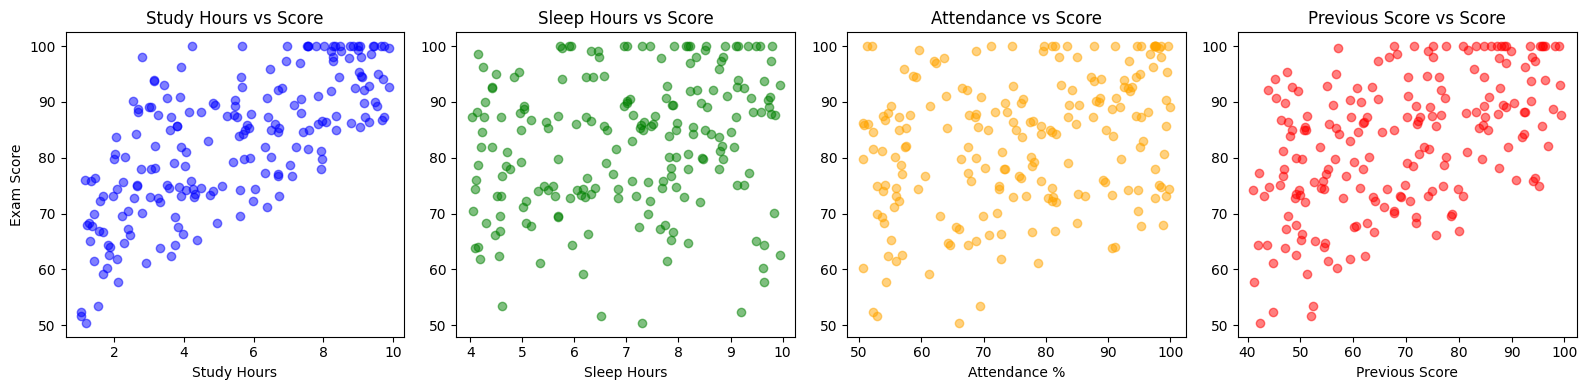

In [3]:
print("Basic Statistics:")
print(data.describe())
# Visualize relationships
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].scatter(data['study_hours'], data['exam_score'], color='blue', alpha=0.5)
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Exam Score')
axes[0].set_title('Study Hours vs Score')

axes[1].scatter(data['sleep_hours'], data['exam_score'], color='green', alpha=0.5)
axes[1].set_xlabel('Sleep Hours')
axes[1].set_title('Sleep Hours vs Score')

axes[2].scatter(data['attendance'], data['exam_score'], color='orange', alpha=0.5)
axes[2].set_xlabel('Attendance %')
axes[2].set_title('Attendance vs Score')

axes[3].scatter(data['prev_score'], data['exam_score'], color='red', alpha=0.5)
axes[3].set_xlabel('Previous Score')
axes[3].set_title('Previous Score vs Score')

plt.tight_layout()
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = data[['study_hours', 'sleep_hours', 'attendance', 'prev_score']]
y = data['exam_score']

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (160, 4)
Testing samples: (40, 4)


In [5]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(4,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 6723.5762 - mae: 81.1166 - val_loss: 7325.8228 - val_mae: 84.9191
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6694.7632 - mae: 80.9358 - val_loss: 7296.1729 - val_mae: 84.7453
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6664.0488 - mae: 80.7472 - val_loss: 7264.8447 - val_mae: 84.5614
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6631.5044 - mae: 80.5446 - val_loss: 7231.3130 - val_mae: 84.3640
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6596.2871 - mae: 80.3251 - val_loss: 7195.3125 - val_mae: 84.1519
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6558.2534 - mae: 80.0879 - val_loss: 7155.3262 - val_mae: 83.9157
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6515.1685 - mae: 79.8171 - val_loss: 7110.8320 - val_mae: 83.6516
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6467.7017 - mae: 79.5178 - val_loss: 7060.7622 - val_mae: 83.3538
Epoch 9/100
4/4

In [7]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Average error in score: {mse**0.5:.2f} marks")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Mean Squared Error: 114.47
R² Score: 0.32
Average error in score: 10.70 marks


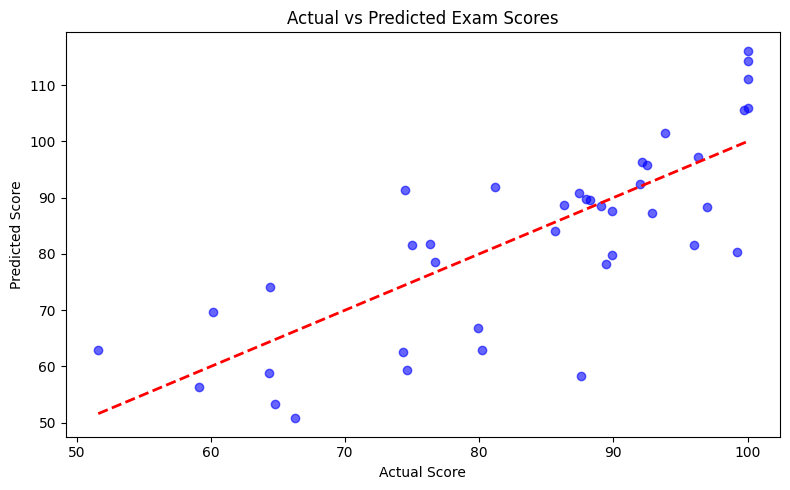

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted Exam Scores')
plt.tight_layout()
plt.show()


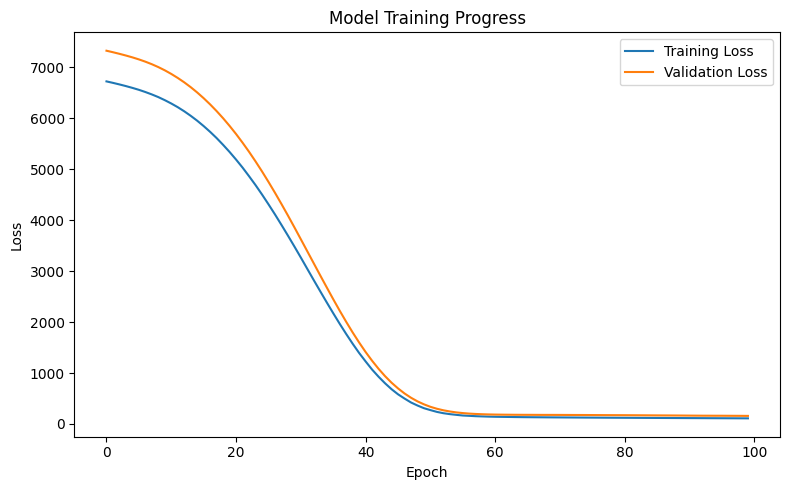

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Average error in score: {mse**0.5:.2f} marks")


Mean Squared Error: 114.47
R² Score: 0.32
Average error in score: 10.70 marks


In [11]:
# Better model
model2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(4,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

history2 = model2.fit(
    X_train, y_train,
    epochs=200,
    validation_split=0.2,
    verbose=0
)

print("Training done!")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training done!


In [12]:
y_pred2 = model2.predict(X_test)
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print(f"Mean Squared Error: {mse2:.2f}")
print(f"R² Score: {r2_2:.2f}")
print(f"Average error in score: {mse2**0.5:.2f} marks")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Mean Squared Error: 30.81
R² Score: 0.82
Average error in score: 5.55 marks


In [13]:
# Best model
model3 = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(4,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model3.compile(optimizer='adam', loss='mse', metrics=['mae'])

history3 = model3.fit(
    X_train, y_train,
    epochs=500,
    validation_split=0.2,
    verbose=0
)

print("Training done!")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training done!


In [14]:
y_pred3 = model3.predict(X_test)
mse3 = mean_squared_error(y_test, y_pred3)
r2_3 = r2_score(y_test, y_pred3)

print(f"Mean Squared Error: {mse3:.2f}")
print(f"R² Score: {r2_3:.2f}")
print(f"Average error in score: {mse3**0.5:.2f} marks")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x1293fd4e0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Mean Squared Error: 12.34
R² Score: 0.93
Average error in score: 3.51 marks


In [15]:
# Predict score for a new student
new_student = np.array([[7.5, 8.0, 90.0, 85.0]])  # study_hours, sleep_hours, attendance, prev_score
new_student_scaled = scaler.transform(new_student)
predicted_score = model3.predict(new_student_scaled)

print(f"Student Profile:")
print(f"  Study Hours : 7.5")
print(f"  Sleep Hours : 8.0")
print(f"  Attendance  : 90%")
print(f"  Prev Score  : 85")
print(f"\nPredicted Exam Score: {predicted_score[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Student Profile:
  Study Hours : 7.5
  Sleep Hours : 8.0
  Attendance  : 90%
  Prev Score  : 85

Predicted Exam Score: 96.82


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
import pickle

# Save the model
model3.save('student_model.keras')

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved!")

Model and scaler saved!
